# Liver Disease — Exploratory Data Analysis

## 1. Introduction

This notebook performs a systematic inspection and exploratory data analysis
of the Liver Disease dataset.

The objective is to understand:

- Dataset structure
- Feature types
- Missing values
- Duplicate records
- Target distribution
- Numerical feature distributions
- Categorical feature distributions
- Outliers
- Relationships between features and the target
- Feature correlations

This analysis will be used as the foundation for the preprocessing and
machine learning pipeline developed later.

## 2. Import Required Libraries

We import the Python libraries required for:

- Data loading and manipulation
- Numerical analysis
- Visualization
- Statistical inspection

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

## 3. Define Dataset Path

The raw Liver Disease dataset is stored in the project's
`data/raw` directory.

We first verify that the expected file exists before loading it.

In [4]:
DATA_PATH = Path("../../data/raw/liver_disease.csv.csv")

print("Dataset path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

Dataset path: ..\..\data\raw\liver_disease.csv.csv
File exists: True


## 4. Load the Dataset

The raw Liver Disease dataset does not contain column headers.

Therefore, the dataset must be loaded with `header=None` so that the
first patient record is preserved as data.

The feature names will be assigned separately based on the dataset structure.

In [11]:
# Load dataset without assuming the first row is a header
liver_df = pd.read_csv(DATA_PATH, header=None)

print("Dataset loaded successfully.")
print("Shape:", liver_df.shape)

display(liver_df.head())

Dataset loaded successfully.
Shape: (583, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 5. Assign Feature Names

The Liver Disease dataset contains 10 clinical features and 1 target
column.

The columns are assigned explicitly because the raw CSV file does not
contain a header row.

In [12]:
liver_columns = [
    "Age",
    "Gender",
    "Total_Bilirubin",
    "Direct_Bilirubin",
    "Alkaline_Phosphotase",
    "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase",
    "Total_Proteins",
    "Albumin",
    "Albumin_and_Globulin_Ratio",
    "Selector"
]

liver_df.columns = liver_columns

print("Columns assigned successfully:")
print(liver_df.columns.tolist())

print("\nShape:", liver_df.shape)

display(liver_df.head())

Columns assigned successfully:
['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio', 'Selector']

Shape: (583, 11)


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


## 6. Basic Dataset Inspection

We inspect the first and last few records to understand the structure
and format of the raw dataset.

In [13]:
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)

display(liver_df.head())

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)

display(liver_df.tail())

FIRST 5 ROWS


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1



LAST 5 ROWS


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


## 7. Dataset Dimensions

The dataset dimensions indicate:

- Number of observations (rows)
- Number of variables (columns)

This provides an initial understanding of the dataset size.

In [14]:
print("Number of rows:", liver_df.shape[0])
print("Number of columns:", liver_df.shape[1])

Number of rows: 583
Number of columns: 11


## 8. Column Names

We inspect all column names to understand which variables are available
in the raw Liver Disease dataset.

The target column will be identified after examining the dataset structure.

In [15]:
print("Columns:")
for i, column in enumerate(liver_df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. Age
2. Gender
3. Total_Bilirubin
4. Direct_Bilirubin
5. Alkaline_Phosphotase
6. Alamine_Aminotransferase
7. Aspartate_Aminotransferase
8. Total_Proteins
9. Albumin
10. Albumin_and_Globulin_Ratio
11. Selector


## 9. Data Types and Dataset Information

We inspect the data types of all variables.

This helps identify:

- Numerical features
- Categorical features
- Potentially incorrectly typed columns
- Columns requiring preprocessing

In [16]:
print("=" * 60)
print("DATA TYPES")
print("=" * 60)

print(liver_df.dtypes)

print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)

liver_df.info()

DATA TYPES
Age                             int64
Gender                            str
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Proteins                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Selector                        int64
dtype: object

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    str    
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    i

## 10. Statistical Summary

For numerical variables, we examine descriptive statistics such as:

- Count
- Mean
- Standard deviation
- Minimum
- Quartiles
- Maximum

These statistics help identify unusual ranges and possible outliers.

In [17]:
print("NUMERICAL FEATURE SUMMARY")
print("=" * 60)

display(liver_df.describe().T)

NUMERICAL FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Proteins,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8
Selector,583.0,1.286449,0.452490,1.0,1.0,1.00,2.0,2.0


## 11. Missing Values

Missing values can affect statistical analysis and machine learning models.

We inspect the number and percentage of missing values in each column before
deciding how they should be handled.

In [18]:
missing_summary = pd.DataFrame({
    "Missing Count": liver_df.isnull().sum(),
    "Missing Percentage": (liver_df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing Count",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
Albumin_and_Globulin_Ratio,4,0.69
Gender,0,0.00
Age,0,0.00
Total_Bilirubin,0,0.00
Direct_Bilirubin,0,0.00
Alamine_Aminotransferase,0,0.00
Alkaline_Phosphotase,0,0.00
Aspartate_Aminotransferase,0,0.00
Total_Proteins,0,0.00
Albumin,0,0.00


## 12. Duplicate Records

Duplicate records can introduce repeated observations into the dataset.

We check for completely duplicated rows before continuing with the analysis.

In [19]:
duplicate_count = liver_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 13


## 13. Unique Values

We inspect the number of unique values in every feature.

This helps identify categorical/discrete variables and potential target
columns.

In [20]:
unique_summary = pd.DataFrame({
    "Unique Values": liver_df.nunique(),
    "Data Type": liver_df.dtypes.astype(str)
})

display(unique_summary)

,Unique Values,Data Type
Age,72,int64
Gender,2,str
Total_Bilirubin,113,float64
Direct_Bilirubin,80,float64
Alkaline_Phosphotase,263,int64
Alamine_Aminotransferase,152,int64
Aspartate_Aminotransferase,177,int64
Total_Proteins,58,float64
Albumin,40,float64
Albumin_and_Globulin_Ratio,69,float64


## 14. Target Variable Identification

The `Selector` column contains two unique values and is therefore a candidate
for the binary target variable.

We inspect its values and distribution before confirming how it should be
used for model training.

In [21]:
target_column = "Selector"

print("Unique target values:")
print(sorted(liver_df[target_column].unique()))

print("\nTarget counts:")
print(liver_df[target_column].value_counts().sort_index())

print("\nTarget percentages:")
target_percentages = (
    liver_df[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print(target_percentages)

Unique target values:
[np.int64(1), np.int64(2)]

Target counts:
Selector
1    416
2    167
Name: count, dtype: int64

Target percentages:
Selector
1    71.36
2    28.64
Name: proportion, dtype: float64


## 15. Target Distribution

The target distribution shows how many observations belong to each class.

This is important for identifying potential class imbalance before model
training.

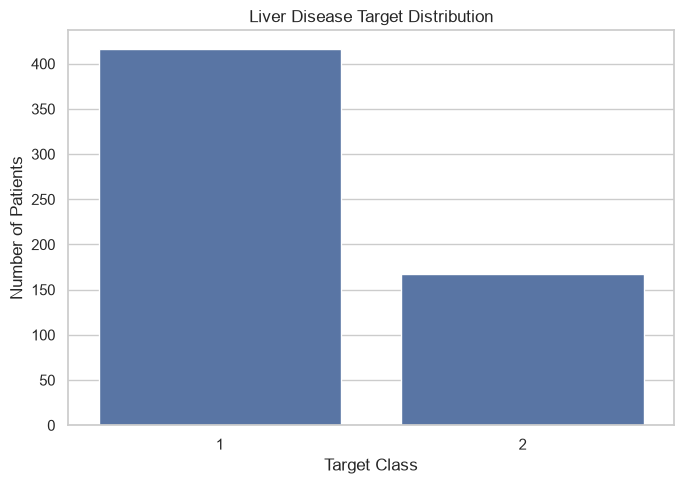

In [22]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=liver_df,
    x=target_column
)

plt.title("Liver Disease Target Distribution")
plt.xlabel("Target Class")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

## 16. Gender Distribution

Gender is the only non-numerical feature in the dataset.

We inspect its unique values and frequency distribution before deciding
how it should be encoded during preprocessing.

Gender values:
Gender
Male      441
Female    142
Name: count, dtype: int64


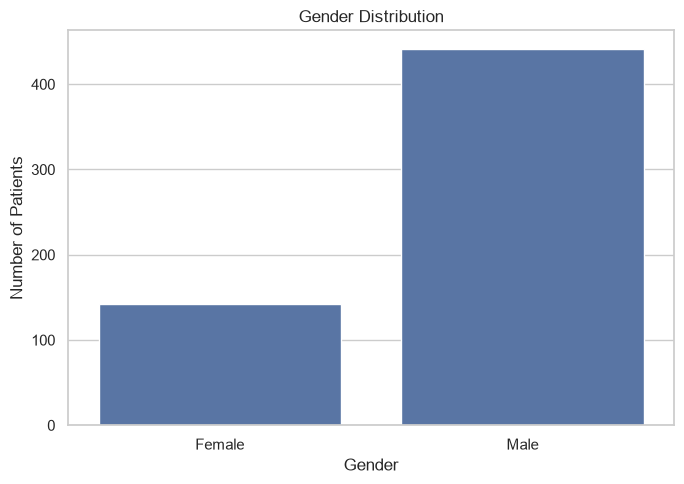

In [24]:
print("Gender values:")
print(liver_df["Gender"].value_counts(dropna=False))

plt.figure(figsize=(7, 5))

sns.countplot(
    data=liver_df,
    x="Gender"
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

## 17. Numerical Feature Distributions

We visualize the distributions of the numerical features to identify:

- Shape of the distributions
- Skewness
- Concentration of observations
- Potential extreme values
- Differences in feature scales

The target column is excluded from this analysis.

In [25]:
numerical_features = [
    column
    for column in liver_df.select_dtypes(include=np.number).columns
    if column != target_column
]

print("Numerical features:")
print(numerical_features)

print("\nNumber of numerical features:", len(numerical_features))

Numerical features:
['Age', 'Total_Bilirubin', 'Direct_Bilirubin', 'Alkaline_Phosphotase', 'Alamine_Aminotransferase', 'Aspartate_Aminotransferase', 'Total_Proteins', 'Albumin', 'Albumin_and_Globulin_Ratio']

Number of numerical features: 9


## 18. Numerical Feature Distribution Plots

Histograms with density curves are used to visualize the distribution
of each numerical feature.

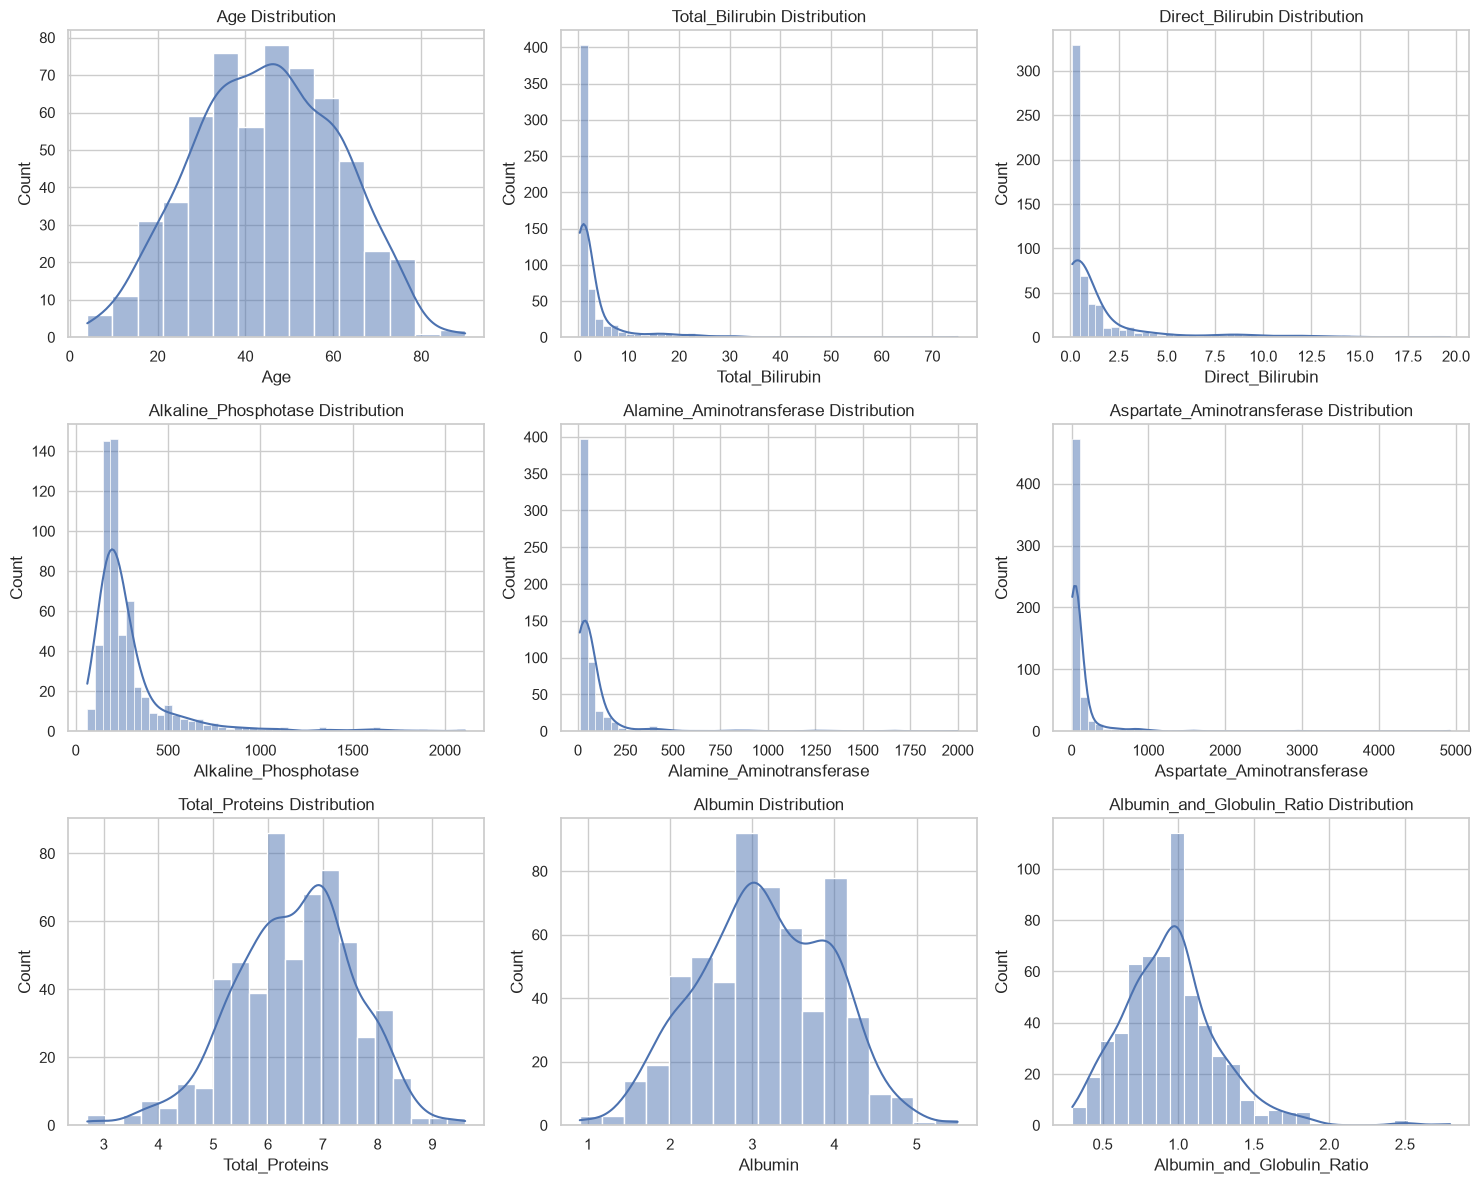

In [26]:
n_features = len(numerical_features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, numerical_features):
    sns.histplot(
        liver_df[column],
        kde=True,
        ax=ax
    )

    ax.set_title(f"{column} Distribution")
    ax.set_xlabel(column)
    ax.set_ylabel("Count")

for ax in axes[len(numerical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

## 19. Numerical Feature Statistics

We calculate summary statistics for each numerical feature to identify
features with different scales and potentially skewed distributions.

In [27]:
numerical_summary = liver_df[numerical_features].describe().T

display(
    numerical_summary[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
)

,count,mean,std,min,25%,50%,75%,max
Age,583.0,44.746141,16.189833,4.0,33.0,45.00,58.0,90.0
Total_Bilirubin,583.0,3.298799,6.209522,0.4,0.8,1.00,2.6,75.0
Direct_Bilirubin,583.0,1.486106,2.808498,0.1,0.2,0.30,1.3,19.7
Alkaline_Phosphotase,583.0,290.576329,242.937989,63.0,175.5,208.00,298.0,2110.0
Alamine_Aminotransferase,583.0,80.713551,182.620356,10.0,23.0,35.00,60.5,2000.0
Aspartate_Aminotransferase,583.0,109.910806,288.918529,10.0,25.0,42.00,87.0,4929.0
Total_Proteins,583.0,6.483190,1.085451,2.7,5.8,6.60,7.2,9.6
Albumin,583.0,3.141852,0.795519,0.9,2.6,3.10,3.8,5.5
Albumin_and_Globulin_Ratio,579.0,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8


## 20. Outlier Detection Using IQR

The Interquartile Range (IQR) method is used to identify potential
outliers in numerical features.

For each feature:

- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Values outside these bounds are flagged as potential outliers.

These observations are not automatically removed because extreme medical
measurements may represent genuine patient observations.

In [28]:
outlier_summary = []

for column in numerical_features:
    q1 = liver_df[column].quantile(0.25)
    q3 = liver_df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (liver_df[column] < lower_bound) |
        (liver_df[column] > upper_bound)
    ).sum()

    outlier_summary.append({
        "Feature": column,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Potential Outliers": int(outlier_count)
    })

outlier_summary = pd.DataFrame(outlier_summary)

display(outlier_summary)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,Age,33.0,58.0,25.0,-4.50,95.50,0
1,Total_Bilirubin,0.8,2.6,1.8,-1.90,5.30,84
2,Direct_Bilirubin,0.2,1.3,1.1,-1.45,2.95,81
3,Alkaline_Phosphotase,175.5,298.0,122.5,-8.25,481.75,69
4,Alamine_Aminotransferase,23.0,60.5,37.5,-33.25,116.75,73
5,Aspartate_Aminotransferase,25.0,87.0,62.0,-68.00,180.00,66
6,Total_Proteins,5.8,7.2,1.4,3.70,9.30,8
7,Albumin,2.6,3.8,1.2,0.80,5.60,0
8,Albumin_and_Globulin_Ratio,0.7,1.1,0.4,0.10,1.70,10


## 21. Numerical Feature Boxplots

Boxplots provide a visual inspection of the potential outliers identified
using the IQR method.

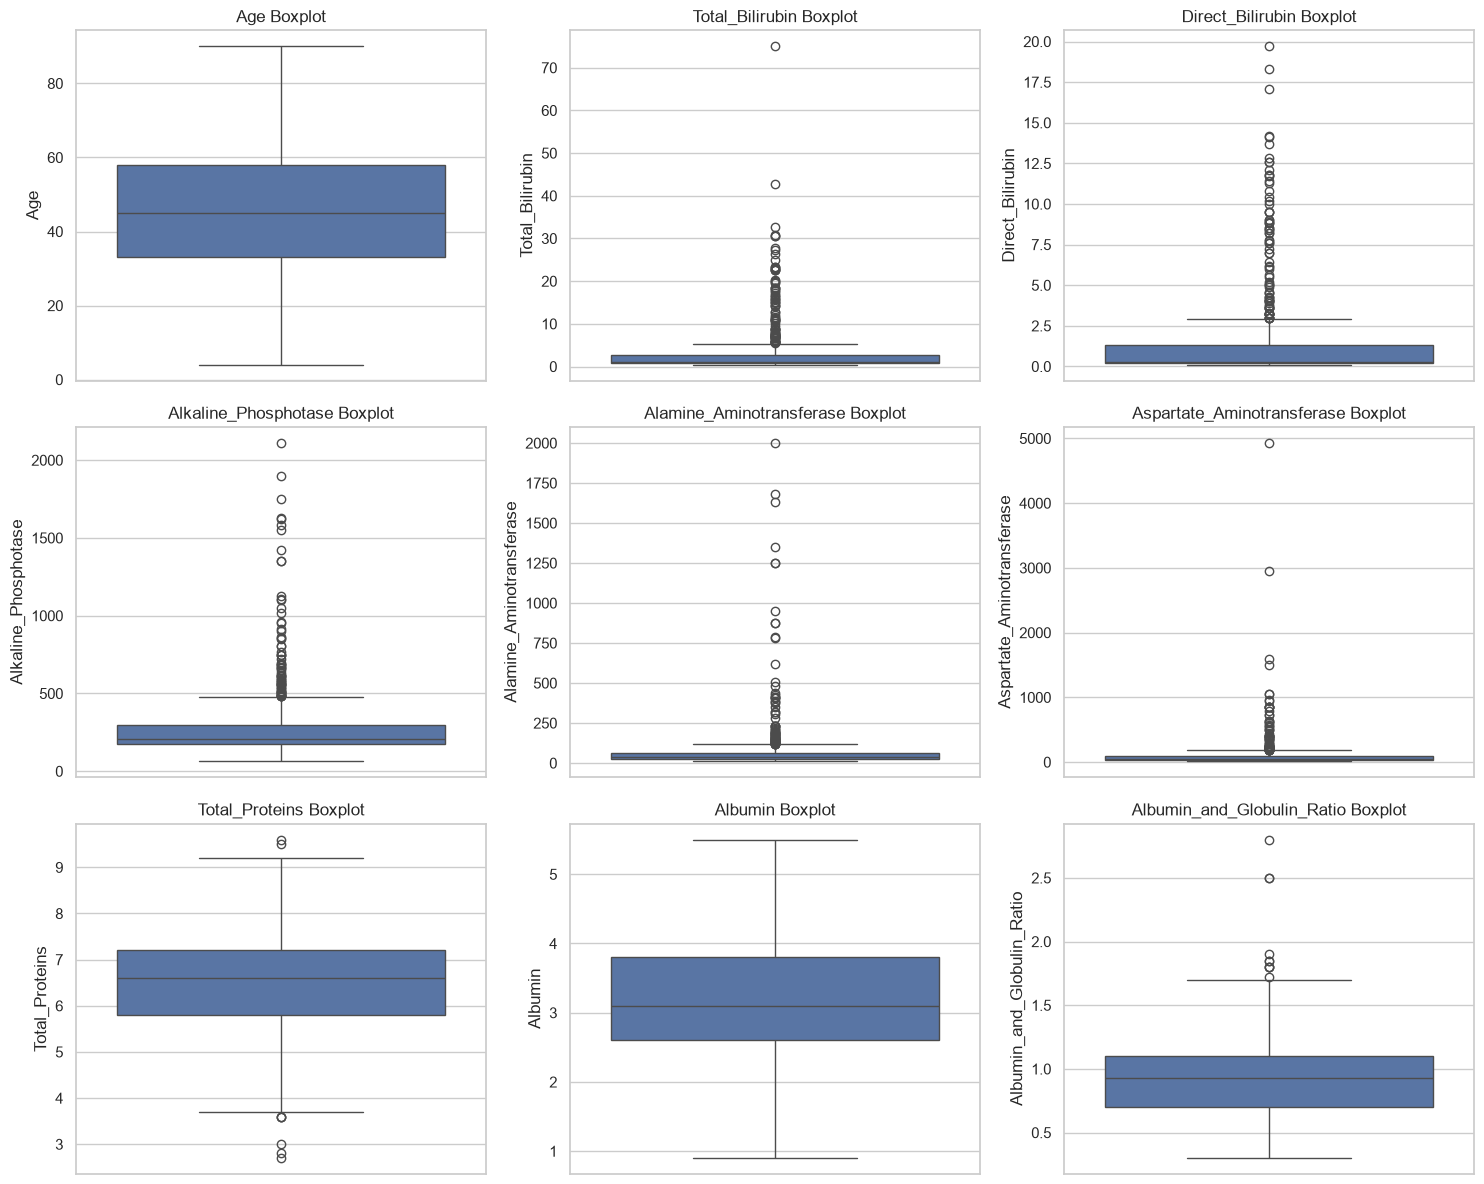

In [29]:
n_features = len(numerical_features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, numerical_features):
    sns.boxplot(
        y=liver_df[column],
        ax=ax
    )

    ax.set_title(f"{column} Boxplot")
    ax.set_ylabel(column)

for ax in axes[len(numerical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

## 22. Numerical Features vs Target

We compare the distributions of numerical features across the two target
classes.

Boxplots are used to identify differences in central tendency, spread,
and extreme values between patients belonging to each target class.

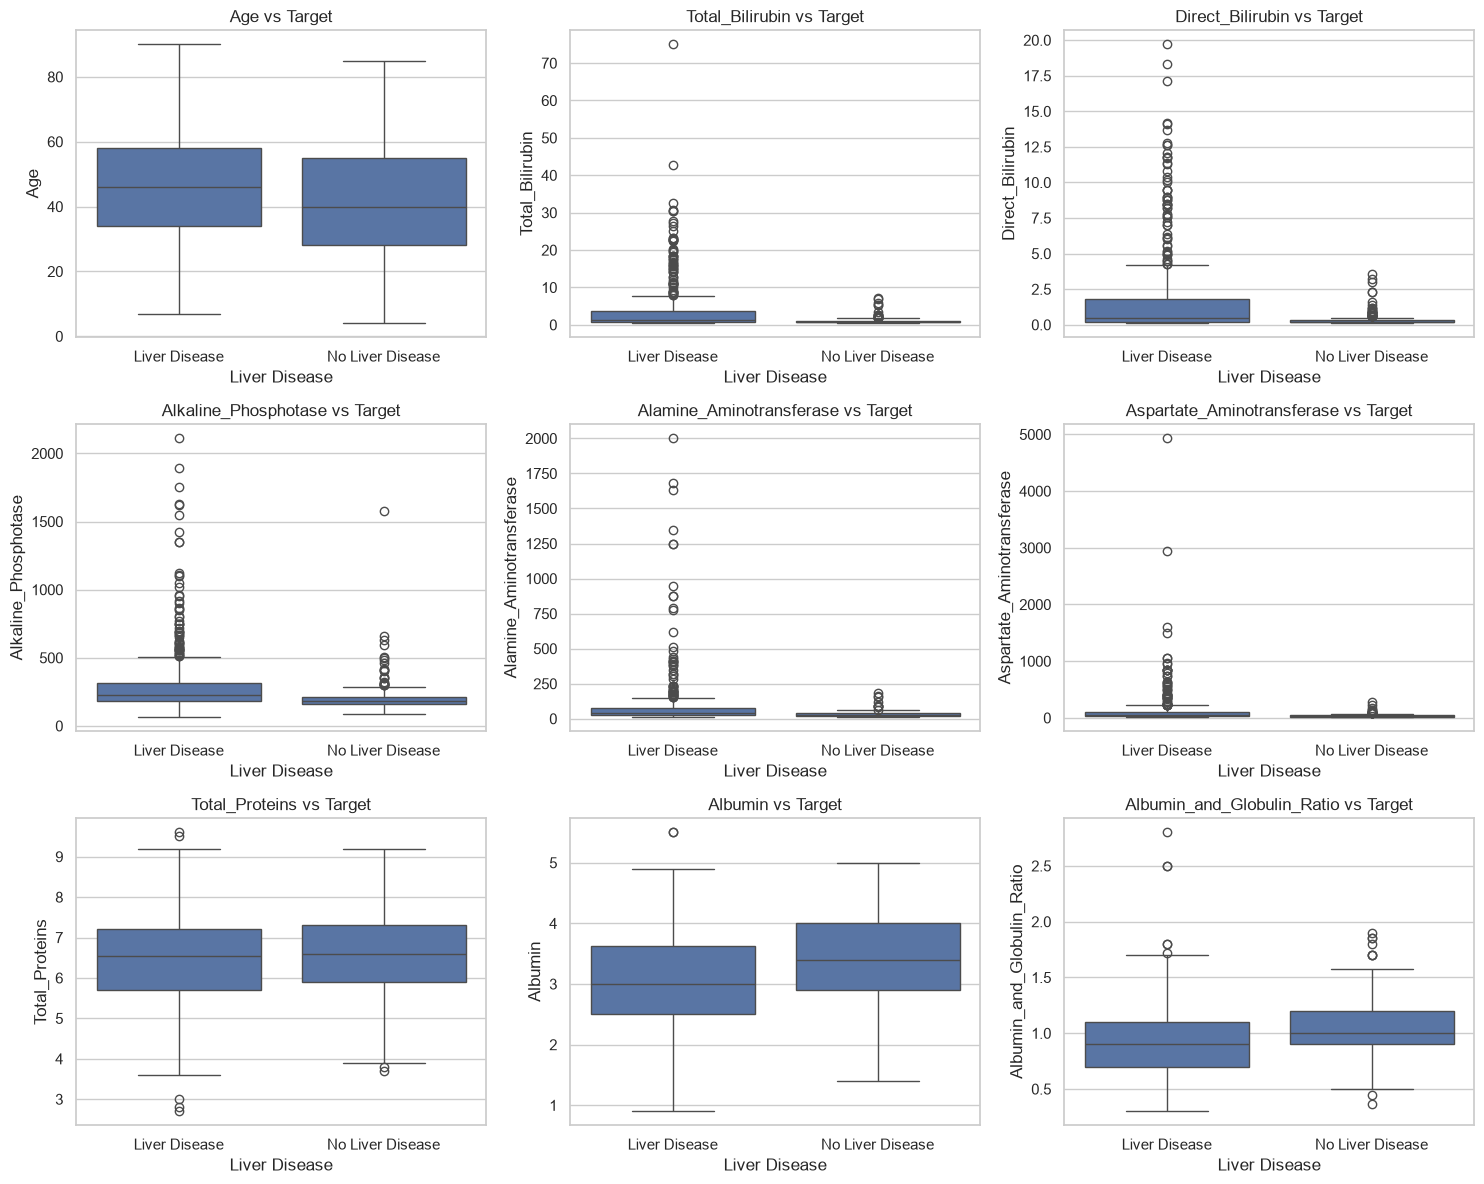

In [30]:
# Create a copy with readable target labels for visualization

liver_plot_df = liver_df.copy()

liver_plot_df["Target"] = liver_plot_df[target_column].map({
    1: "Liver Disease",
    2: "No Liver Disease"
})

n_features = len(numerical_features)
n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = np.array(axes).reshape(-1)

for ax, column in zip(axes, numerical_features):

    sns.boxplot(
        data=liver_plot_df,
        x="Target",
        y=column,
        ax=ax
    )

    ax.set_title(f"{column} vs Target")
    ax.set_xlabel("Liver Disease")
    ax.set_ylabel(column)

for ax in axes[len(numerical_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

## 23. Numerical Features by Target Class

Mean, median, and standard deviation are calculated separately for each
target class to provide a quantitative comparison of numerical features.

In [32]:
target_numeric_summary = liver_df.groupby(target_column)[
    numerical_features
].agg(["mean", "median", "std"])

display(
    target_numeric_summary.round(2)
)

Age               Total_Bilirubin              Direct_Bilirubin  \
           mean median    std            mean median   std             mean   
Selector                                                                      
1         46.15   46.0  15.65            4.16    1.4  7.14             1.92   
2         41.24   40.0  17.00            1.14    0.8  1.00             0.40   

                      Alkaline_Phosphotase                 \
         median   std                 mean median     std   
Selector                                                    
1           0.5  3.21               319.01  229.0  268.31   
2           0.2  0.52               219.75  186.0  140.99   

         Alamine_Aminotransferase                Aspartate_Aminotransferase  \
                             mean median     std                       mean   
Selector                                                                      
1                           99.61   41.0  212.77                     137.70   
2                           33.65   27.0   25.06                      40.69   

                        Total_Proteins              Albumin               \
         median     std           mean median   std    mean median   std   
Selector                                                                   
1          52.5  337.39           6.46   6.55  1.09    3.06    3.0  0.79   
2          29.0   36.41           6.54   6.60  1.06    3.34    3.4  0.78   

         Albumin_and_Globulin_Ratio               
                               mean median   std  
Selector                                          
1                              0.91    0.9  0.33  
2                              1.03    1.0  0.29

## 24. Gender vs Liver Disease Target

Gender is a categorical feature with two observed categories: Male and Female.

We compare the target distribution within each gender to understand whether
the proportion of liver-disease observations differs between the groups.

In [34]:
gender_target_counts = pd.crosstab(
    liver_df["Gender"],
    liver_df[target_column]
)

print("Gender vs Target Counts:")
display(gender_target_counts)

Gender vs Target Counts:


Selector,1,2
Gender,,
Female,92,50
Male,324,117


## 25. Gender vs Target Proportions

Proportions are calculated within each gender so that the target distribution
can be compared fairly despite the unequal number of male and female records.

In [35]:
gender_target_proportions = pd.crosstab(
    liver_df["Gender"],
    liver_df[target_column],
    normalize="index"
) * 100

print("Gender vs Target Percentages:")
display(gender_target_proportions.round(2))

Gender vs Target Percentages:


Selector,1,2
Gender,,
Female,64.79,35.21
Male,73.47,26.53


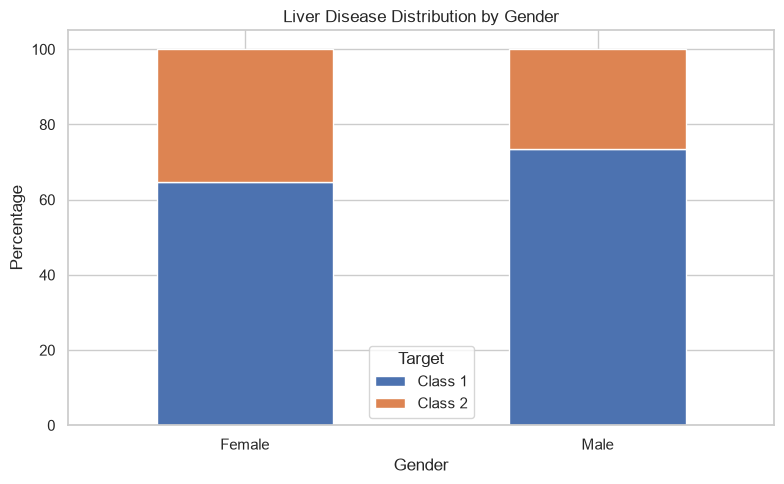

In [37]:
gender_target_proportions.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Liver Disease Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.legend(
    title="Target",
    labels=["Class 1", "Class 2"]
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 26. Correlation Analysis

Correlation analysis is used to examine the linear relationships between
numerical features and the target variable.

The analysis helps identify:

- Strong relationships between numerical features
- Potentially redundant features
- The direction and strength of numerical associations with the target

Correlation does not imply causation.

In [38]:
# Create correlation matrix
correlation_data = liver_df[
    numerical_features + [target_column]
].corr()

print("Correlation Matrix:")
display(correlation_data.round(2))

Correlation Matrix:


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Selector
Age,1.00,0.01,0.01,0.08,-0.09,-0.02,-0.19,-0.27,-0.22,-0.14
Total_Bilirubin,0.01,1.00,0.87,0.21,0.21,0.24,-0.01,-0.22,-0.21,-0.22
Direct_Bilirubin,0.01,0.87,1.00,0.23,0.23,0.26,-0.00,-0.23,-0.20,-0.25
Alkaline_Phosphotase,0.08,0.21,0.23,1.00,0.13,0.17,-0.03,-0.17,-0.23,-0.18
Alamine_Aminotransferase,-0.09,0.21,0.23,0.13,1.00,0.79,-0.04,-0.03,-0.00,-0.16
Aspartate_Aminotransferase,-0.02,0.24,0.26,0.17,0.79,1.00,-0.03,-0.09,-0.07,-0.15
Total_Proteins,-0.19,-0.01,-0.00,-0.03,-0.04,-0.03,1.00,0.78,0.23,0.04
Albumin,-0.27,-0.22,-0.23,-0.17,-0.03,-0.09,0.78,1.00,0.69,0.16
Albumin_and_Globulin_Ratio,-0.22,-0.21,-0.20,-0.23,-0.00,-0.07,0.23,0.69,1.00,0.16
Selector,-0.14,-0.22,-0.25,-0.18,-0.16,-0.15,0.04,0.16,0.16,1.00


## 27. Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix.
Higher absolute correlation values indicate stronger linear relationships.

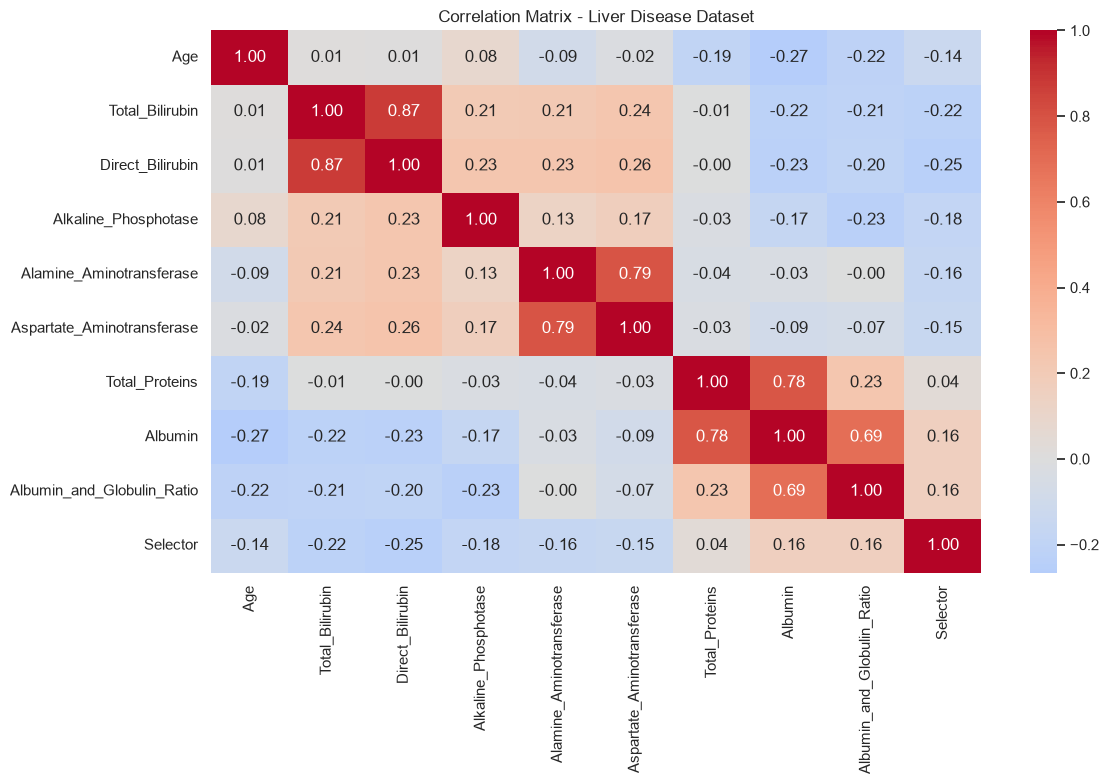

In [40]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Liver Disease Dataset")

plt.tight_layout()
plt.show()

## 28. Missing Value Analysis

Missing values are inspected to determine their location and proportion
within the dataset.

This step helps determine the appropriate preprocessing strategy before
model training.

In [41]:
missing_summary = pd.DataFrame({
    "Missing Count": liver_df.isnull().sum(),
    "Missing Percentage": (
        liver_df.isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "Missing Count",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
Albumin_and_Globulin_Ratio,4,0.69
Gender,0,0.00
Age,0,0.00
Total_Bilirubin,0,0.00
Direct_Bilirubin,0,0.00
Alamine_Aminotransferase,0,0.00
Alkaline_Phosphotase,0,0.00
Aspartate_Aminotransferase,0,0.00
Total_Proteins,0,0.00
Albumin,0,0.00


## 29. Missing Value Visualization

Only features containing missing observations are visualized.

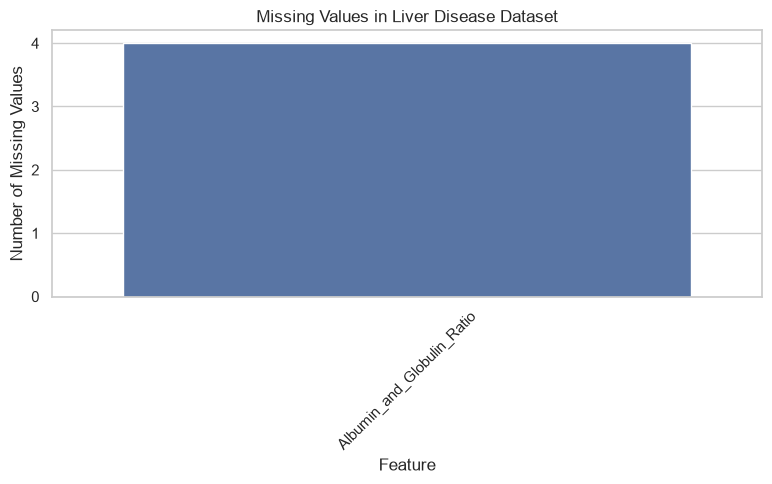

In [42]:
missing_plot = missing_summary[
    missing_summary["Missing Count"] > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(8, 5))

    sns.barplot(
        x=missing_plot.index,
        y=missing_plot["Missing Count"]
    )

    plt.title("Missing Values in Liver Disease Dataset")
    plt.xlabel("Feature")
    plt.ylabel("Number of Missing Values")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("No missing values found.")

## 30. Duplicate Record Analysis

Duplicate records are checked to identify completely repeated observations.

Duplicate rows can affect model training by giving repeated observations
additional influence, so they will be reviewed before preprocessing.

In [43]:
duplicate_count = liver_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("\nDuplicate percentage:")
    print(round((duplicate_count / len(liver_df)) * 100, 2), "%")

Number of duplicate rows: 13

Duplicate percentage:
2.23 %


## 31. Duplicate Records Summary

The number and percentage of duplicate records are reported before
deciding whether they should be removed during data cleaning.

In [44]:
duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Duplicate Rows",
        "Duplicate Percentage"
    ],
    "Value": [
        len(liver_df),
        duplicate_count,
        round((duplicate_count / len(liver_df)) * 100, 2)
    ]
})

display(duplicate_summary)

,Metric,Value
0,Total Rows,583.00
1,Duplicate Rows,13.00
2,Duplicate Percentage,2.23


## 32. Exploratory Data Analysis Summary

The liver disease dataset contains 583 observations and 11 columns.

Key findings from the exploratory analysis:

- The target variable `Selector` contains two classes:
  - Class 1: 416 observations (71.36%)
  - Class 2: 167 observations (28.64%)
- `Gender` contains two categories: Male and Female.
- `Albumin_and_Globulin_Ratio` contains 4 missing values (0.69%).
- The dataset contains 13 duplicate records (2.23%).
- Several numerical features show strong right-skewed distributions.
- Multiple potential outliers were identified, particularly in bilirubin
  and liver-enzyme measurements.
- Strong correlations were observed between:
  - `Total_Bilirubin` and `Direct_Bilirubin`
  - `Alamine_Aminotransferase` and `Aspartate_Aminotransferase`
  - `Total_Proteins` and `Albumin`
- Numerical features show different distributions across the target classes.
- Gender also shows different target proportions in this dataset.

These findings will guide the subsequent data cleaning and preprocessing
steps.

## 33. Data Cleaning

Based on the inspection results, the dataset is prepared for modeling.

The cleaning process includes:

1. Removing completely duplicated observations.
2. Handling missing values using a preprocessing strategy.
3. Keeping potential medical outliers rather than removing them solely
   based on the IQR rule.
4. Preserving the original dataset for reference.

In [45]:
# Create a clean copy of the original dataset
liver_clean_df = liver_df.copy()

# Remove completely duplicated rows
duplicates_before = liver_clean_df.duplicated().sum()

liver_clean_df = liver_clean_df.drop_duplicates().reset_index(drop=True)

duplicates_after = liver_clean_df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicates_before)
print("Duplicate rows removed:", duplicates_before - duplicates_after)
print("Duplicate rows after cleaning:", duplicates_after)

print("\nCleaned dataset shape:", liver_clean_df.shape)

Duplicate rows before cleaning: 13
Duplicate rows removed: 13
Duplicate rows after cleaning: 0

Cleaned dataset shape: (570, 11)
